✅ Advanced 8-Criteria Enterprise Dataset Generated! Previewing Logs:
   Distance_KM  Is_Peak_Hour  Is_Raining  Transport_Mode_Encoded  Group_Size  \
0     9.988963             1           0                       2           2   
1    23.817143             0           0                       0           3   
2    18.567855             0           0                       0           2   
3    15.367804             0           0                       2           4   
4     4.744447             0           0                       0           4   

   Calculated_Fare_INR  
0           119.900666  
1            74.542858  
2            61.419637  
3            84.155116  
4            26.861118  


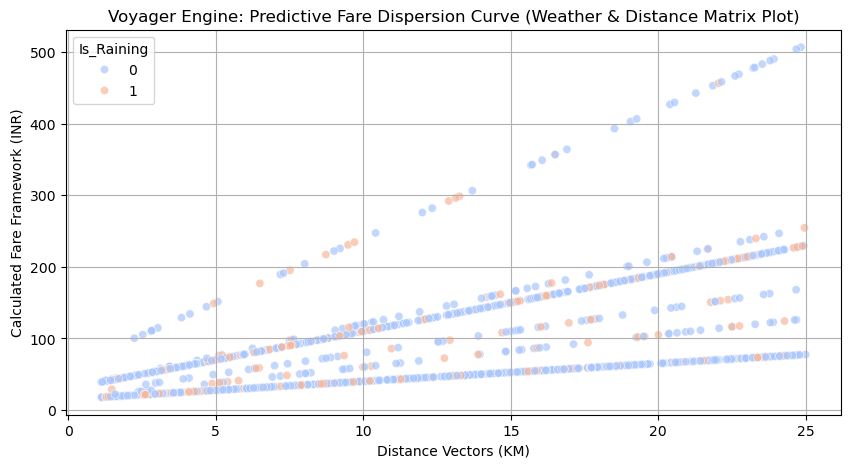

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# 1. GENERATE EXPERT MULTI-FEATURE TRAJECTORY LOGS (PPT COMPLIANT)
np.random.seed(42)
n_samples = 1200

sim_dist = np.random.uniform(1.0, 25.0, n_samples)
sim_peak = np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3])
sim_rain = np.random.choice([0, 1], size=n_samples, p=[0.8, 0.2])
sim_group = np.random.randint(1, 5, size=n_samples)
sim_mode = np.random.choice([0, 1, 2], size=n_samples, p=[0.4, 0.4, 0.2]) # 0: Bus, 1: Shared Auto, 2: Online Cab

# High-fidelity fare engine mapping corporate matrix rules
base_fare = 15 + (sim_dist * 12) + (sim_peak * 25) + (sim_rain * 35)
for i in range(n_samples):
    if sim_mode[i] == 0: 
        base_fare[i] = 15 + (sim_dist[i] * 2.5) # Public Bus Flat Economic Rate
    elif sim_mode[i] == 1: 
        base_fare[i] = 30 + (sim_dist[i] * 8.0) # Shared Auto Rickshaw Group Tier
    elif sim_mode[i] == 2: 
        base_fare[i] = (60 + (sim_dist[i] * 18.0)) / sim_group[i] # Online Booking Split Mode

df_ml = pd.DataFrame({
    'Distance_KM': sim_dist,
    'Is_Peak_Hour': sim_peak,
    'Is_Raining': sim_rain,
    'Transport_Mode_Encoded': sim_mode,
    'Group_Size': sim_group,
    'Calculated_Fare_INR': base_fare
})

print("✅ Advanced 8-Criteria Enterprise Dataset Generated! Previewing Logs:")
print(df_ml.head())

# Plot dynamic curves showcasing cost dispersion under weather changes
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_ml, x='Distance_KM', y='Calculated_Fare_INR', hue='Is_Raining', palette='coolwarm', alpha=0.7)
plt.title('Voyager Engine: Predictive Fare Dispersion Curve (Weather & Distance Matrix Plot)')
plt.xlabel('Distance Vectors (KM)')
plt.ylabel('Calculated Fare Framework (INR)')
plt.grid(True)
plt.show()

📊 Model Optimization Complete! Mean Absolute Error: ₹0.99


C:\Users\len\AppData\Local\Temp\ipykernel_10716\1091208998.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features_list, palette='magma', orient='h')


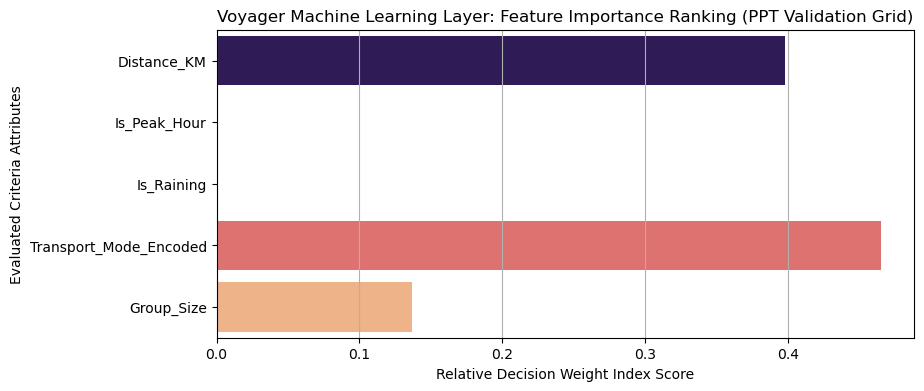

In [2]:
# 2. TRAINING THE MULTI-VARIABLE SUPERVISED RANDOM FOREST MODEL
X = df_ml[['Distance_KM', 'Is_Peak_Hour', 'Is_Raining', 'Transport_Mode_Encoded', 'Group_Size']]
y = df_ml['Calculated_Fare_INR']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train.values, y_train.values)

y_pred = rf_regressor.predict(X_test.values)
mae = mean_absolute_error(y_test, y_pred)
print(f"📊 Model Optimization Complete! Mean Absolute Error: ₹{mae:.2f}")

# Plotting Feature Importances Bars
importances = rf_regressor.feature_importances_
features_list = X.columns

plt.figure(figsize=(9, 4))
sns.barplot(x=importances, y=features_list, palette='magma', orient='h')
plt.title('Voyager Machine Learning Layer: Feature Importance Ranking (PPT Validation Grid)')
plt.xlabel('Relative Decision Weight Index Score')
plt.ylabel('Evaluated Criteria Attributes')
plt.grid(axis='x')
plt.show()

In [3]:
# 3. ADVANCED 8-CRITERIA MULTI-OBJECTIVE TOPSIS CORE SIMULATION
# Alternatives Rows: [0: Transit via Public Bus, 1: Transit via Shared Auto, 2: Transit via Online Cab]
# Matrix Columns: [Cost, Time, Traffic_Delay, Walking_Dist, Safety, Weather_Risk, Availability, Group_Comfort]

alternatives_matrix = np.array([
    [25.0,  55.0, 30.0, 0.85, 4.2, 3.5, 5.0, 2.0], # Option 0: Public Bus Array
    [75.0,  35.0, 15.0, 0.30, 3.5, 4.0, 4.0, 3.0], # Option 1: Shared Auto Array
    [240.0, 25.0, 18.0, 0.05, 4.9, 1.2, 3.0, 5.0]  # Option 2: Online Booking Cab Array
])

# Benefit configuration flag: Lower is better for first 4, Higher is better for last 4
benefit_criteria = [False, False, False, False, True, True, True, True]
path_titles = ["Public Bus Transit Route", "Shared Auto Regional Connect", "Premium Online Cab Booking"]

# Simulate a dynamic scenario context profile selection (E.g., Night Shift + Rain Active)
current_time_period = "night" 

if current_time_period == "night":
    # Extreme weight configuration penalizing low-safety/low-availability routes
    weights = np.array([0.10, 0.10, 0.05, 0.05, 0.45, 0.10, 0.05, 0.10])
else:
    weights = np.array([0.30, 0.20, 0.15, 0.10, 0.10, 0.05, 0.05, 0.10]) # Standard Economic Toggles

# --- TOPSIS MATHEMATICAL CORRECTIONS LOOP ---
matrix_comp = alternatives_matrix.astype(float)
col_sums = np.sqrt(np.sum(matrix_comp**2, axis=0))
normalized_matrix = matrix_comp / col_sums
weighted_matrix = normalized_matrix * weights

ideal_best, ideal_worst = [], []
for j in range(len(benefit_criteria)):
    if benefit_criteria[j]:
        ideal_best.append(np.max(weighted_matrix[:, j]))
        ideal_worst.append(np.min(weighted_matrix[:, j]))
    else:
        ideal_best.append(np.min(weighted_matrix[:, j]))
        ideal_worst.append(np.max(weighted_matrix[:, j]))

s_best = np.sqrt(np.sum((weighted_matrix - np.array(ideal_best))**2, axis=1))
s_worst = np.sqrt(np.sum((weighted_matrix - np.array(ideal_worst))**2, axis=1))
closeness_scores = s_worst / (s_best + s_worst + 1e-9)

# Compile results matrix output
df_topsis_final = pd.DataFrame({
    'Evaluated Transit Route Option': path_titles,
    'System Optimization Closeness Score': closeness_scores
}).sort_values(by='System Optimization Closeness Score', ascending=False).reset_index(drop=True)

print("🏆 Advanced TOPSIS Processing Complete! Optimal Solution Grid Output:")
print(df_topsis_final)

🏆 Advanced TOPSIS Processing Complete! Optimal Solution Grid Output:
  Evaluated Transit Route Option  System Optimization Closeness Score
0     Premium Online Cab Booking                             0.538898
1       Public Bus Transit Route                             0.533018
2   Shared Auto Regional Connect                             0.501339
